# Phase 1.1 — Dubins car: decoupling matrix A(x) invertibility check

This notebook is **fully self-contained**: it (i) states the Dubins system, (ii) derives $A(\bm x)$ and $\det A(\bm x)$ symbolically (SymPy), (iii) samples the synthesis region and evaluates $A$ analytically in Python (validated against the in-notebook symbolic $A$), (iv) confirms $\sigma_{\min}(A)\ge\epsilon$ over $\mathcal X_S\setminus\mathcal X_T$ and visualizes the output-space coverage, and (v) writes `phase1_1_outputs_dubins.json`.

No main-repo data or code is read at runtime; all inputs are generated here and all outputs go to `revision/data/`.


## 0. Parameters

All parameters used in this notebook.

### State / output / sets

| Item                 | Definition                                                                         |
| -------------------- | ---------------------------------------------------------------------------------- |
| state                | $\bm x=(x_1,x_2,\theta,v)$ (position, heading, speed)                              |
| input                | $\bm u=(\dot\theta,\dot v)$                                                        |
| output               | $\bm y=(x_1,x_2)$                                                                  |
| $A(\bm x)$           | $\begin{bmatrix}-v\sin\theta & \cos\theta\\ v\cos\theta & \sin\theta\end{bmatrix}$ |
| $\det A$             | $-v$                                                                               |
| $h_{\rm raw}(\bm y)$ | $-(y_1^4+y_2^4-16)(y_1^4+y_2^4-4)$                                                 |
| target set           | $y_2^2+((y_1+1.7)/0.5)^2-0.4 \le 0$ (ellipse centered $(-1.7,0)$)                  |
| safe set             | $\mathrm{safe}(\bm y)=10^{-3}(-\text{target}+300)\,h_{\rm raw} \ge 0$              |

### Sampling region $\mathcal X_S$ and check parameters

| Parameter               | Symbol     | Value               |
| ----------------------- | ---------- | ------------------- |
| position range          | $x_1, x_2$ | $[-2,\ 2]$          |
| heading range           | $\theta$   | $[2\pi/3,\ 4\pi/3]$ |
| speed range             | $v$        | $[0.1,\ 1.0]$       |
| sample count            | $N$        | $30000$             |
| RNG seed                | —          | $42$                |
| invertibility threshold | $\epsilon$ | $10^{-3}$           |

Samples are generated here (NumPy) and $A$ is evaluated analytically. Since $\det A = -v$ is position-independent and $v\in[0.1,1.0]$, no region relaxation is needed: the box already spans the full safe band.


## 1. System and decoupling matrix

Control-affine dynamics $\dot{\bm x} = \bm f(\bm x) + \bm g(\bm x)\bm u$ with

$$
\bm f(\bm x) = (v\cos\theta,\ v\sin\theta,\ 0,\ 0)^\top, \qquad
\bm g = [\,e_3\ \ e_4\,], \qquad \bm y = \bm h(\bm x) = (x_1, x_2).
$$

Relative degree $\rho=2$, $\bm y^{(2)} = A(\bm x)\bm u + \bm b(\bm x)$ with

$$
\boxed{\,A(\bm x) = \begin{bmatrix} -v\sin\theta & \cos\theta \\ v\cos\theta & \sin\theta \end{bmatrix}\,}, \qquad
\det A(\bm x) = -v.
$$

$A$ is singular only at $v=0$; the box $v\in[0.1,1]$ structurally avoids it. The SymPy cell below re-derives this; the Python evaluator used afterwards is validated against it.


In [7]:
import sympy as sp
from IPython.display import display, Math

x1, x2, th, v = sp.symbols("x1 x2 theta v", real=True)
xs = sp.Matrix([x1, x2, th, v])

f = sp.Matrix([v * sp.cos(th), v * sp.sin(th), 0, 0])
g = sp.Matrix([[0, 0], [0, 0], [1, 0], [0, 1]])
h = sp.Matrix([x1, x2])

ydot = h.jacobian(xs) * f
A_sym = sp.simplify(ydot.jacobian(xs) * g)  # d(yddot)/du = A(x)
det_A = sp.simplify(A_sym.det())

display(Math(r"A(\boldsymbol x) = " + sp.latex(A_sym)))
display(Math(r"\det A(\boldsymbol x) = " + sp.latex(det_A)))

# callable form of the symbolic A, used to validate the Python evaluator below
A_sym_fun = sp.lambdify((th, v), A_sym, "numpy")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 2. Setup, analytic $A$ evaluator, and self-contained sampling

`A_metrics` evaluates $A(\bm x)$ and its conditioning in vectorized form (2x2 closed-form SVD); it is validated against the symbolic $A$ from §1 (NumPy SVD of `A_sym_fun`). Samples are drawn here over the box in the parameter table; safe / target membership is evaluated from the output-space polynomials.


In [8]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np

HERE = os.path.abspath(os.getcwd())
ROOT = HERE
for _ in range(5):
    if os.path.isdir(os.path.join(ROOT, "revision")):
        break
    ROOT = os.path.dirname(ROOT)
REV_DATA = os.path.join(ROOT, "revision", "data")
os.makedirs(REV_DATA, exist_ok=True)


def safe_poly(y1, y2):
    h_raw = -(y1**4 + y2**4 - 16) * (y1**4 + y2**4 - 4)
    target = y2**2 + ((y1 + 1.7) / 0.5) ** 2 - 0.4
    return 1e-3 * (-target + 300) * h_raw


def target_poly(y1, y2):
    return y2**2 + ((y1 + 1.7) / 0.5) ** 2 - 0.4


def A_metrics(theta, v):
    """Return (|det A|, sigma_min(A), cond(A)) for the Dubins decoupling matrix, vectorized."""
    theta = np.asarray(theta, float)
    v = np.asarray(v, float)
    s, c = np.sin(theta), np.cos(theta)
    A11, A12, A21, A22 = -v * s, c, v * c, s
    detA = A11 * A22 - A12 * A21
    frob2 = A11**2 + A12**2 + A21**2 + A22**2
    disc = np.sqrt(np.maximum(frob2**2 - 4 * detA**2, 0.0))
    sig_min = np.sqrt(np.maximum((frob2 - disc) / 2, 0.0))
    sig_max = np.sqrt((frob2 + disc) / 2)
    return np.abs(detA), sig_min, sig_max / np.maximum(sig_min, 1e-300)


# sampling region (parameter table)
EPS = 1e-3
N_SAMPLES = 80000
SEED = 42
TH_LO, TH_HI = 2 * np.pi / 3, 4 * np.pi / 3
V_LO, V_HI = 0.1, 1.0
POS_LO, POS_HI = -2.0, 2.0

rng = np.random.default_rng(SEED)
sx1 = rng.uniform(POS_LO, POS_HI, N_SAMPLES)
sx2 = rng.uniform(POS_LO, POS_HI, N_SAMPLES)
sth = rng.uniform(TH_LO, TH_HI, N_SAMPLES)
sv = rng.uniform(V_LO, V_HI, N_SAMPLES)
absdet, sig, cond = A_metrics(sth, sv)
in_safe = safe_poly(sx1, sx2) >= 0
in_RA = in_safe & (target_poly(sx1, sx2) > 0)  # X_S \ X_T

# validate the Python evaluator against the symbolic A (NumPy SVD of A_sym_fun)
k = 2000
sig_sym = np.array(
    [
        np.linalg.svd(A_sym_fun(t, vv), compute_uv=False).min()
        for t, vv in zip(sth[:k], sv[:k])
    ]
)
print(f"ROOT = {ROOT}")
print(
    f"A_metrics vs symbolic A (first {k} samples): max|sigma_min diff| = {np.abs(sig[:k] - sig_sym).max():.2e}  (should be ~0)"
)
print(
    f"total samples: {N_SAMPLES},  in safe: {int(in_safe.sum())},  in X_S\\X_T: {int(in_RA.sum())}"
)

ROOT = /home/jianqiang/Downloads/reach_avoid_backstepping_MPC
A_metrics vs symbolic A (first 2000 samples): max|sigma_min diff| = 2.35e-14  (should be ~0)
total samples: 80000,  in safe: 37039,  in X_S\X_T: 33929


## 3. Invertibility over $\mathcal X_S\setminus\mathcal X_T$

Quantiles of $|\det A|$, $\sigma_{\min}(A)$, $\mathrm{cond}(A)$ over the safe set, then the binding minimum over $\mathcal X_S\setminus\mathcal X_T$.


In [9]:
import pandas as pd


def pcts(s, qs=(0.0, 0.05, 0.5, 0.95, 0.99)):
    return {
        f"p{int(q*100):02d}" if q > 0 else "min": float(np.quantile(s, q)) for q in qs
    }


rows = []
for arr, name in [
    (absdet[in_safe], "|det A|"),
    (sig[in_safe], "sigma_min(A)"),
    (cond[in_safe], "cond(A)"),
]:
    rows.append({"quantity": name, **pcts(arr), "max": float(arr.max())})
stats_df = pd.DataFrame(rows).set_index("quantity")

sig_RA = sig[in_RA]
absdet_RA = absdet[in_RA]
min_sigma = float(sig_RA.min())
print(f"X_S\\X_T candidates: {int(in_RA.sum())} / {N_SAMPLES}")
print(
    f"X_S\\X_T |det A|:   min={absdet_RA.min():.4f}, median={np.median(absdet_RA):.4f}"
)
print(
    f"X_S\\X_T sigma_min: min={min_sigma:.4f}  (epsilon={EPS:.0e}),  max cond={cond[in_RA].max():.2f}"
)
print(f"all sigma_min >= epsilon over X_S\\X_T ? {bool((sig_RA >= EPS).all())}")
stats_df

X_S\X_T candidates: 33929 / 80000
X_S\X_T |det A|:   min=0.1001, median=0.5475
X_S\X_T sigma_min: min=0.1001  (epsilon=1e-03),  max cond=9.99
all sigma_min >= epsilon over X_S\X_T ? True


,min,p05,p50,p95,p99,max
quantity,,,,,,
|det A|,0.100103,0.144845,0.546906,0.952971,0.989897,0.999988
sigma_min(A),0.100103,0.144845,0.546906,0.952971,0.989897,0.999988
cond(A),1.000012,1.049350,1.828469,6.903927,9.138452,9.989671


## 4. Output-space coverage colored by $|\det A|$

$\mathcal X_S\setminus\mathcal X_T$ samples in the $(y_1,y_2)=(x_1,x_2)$ plane, colored by $|\det A|=v$, with the safe boundary (red) and target boundary (green). The color stays well away from $0$ across the whole region.


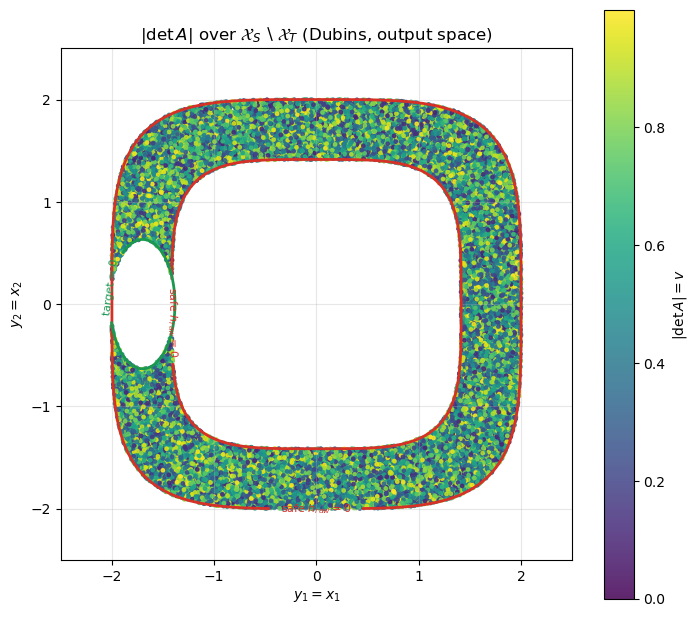

In [10]:
yy = np.linspace(-2.5, 2.5, 400)
Y1, Y2 = np.meshgrid(yy, yy)
H_raw = -(Y1**4 + Y2**4 - 16) * (Y1**4 + Y2**4 - 4)
Tgt = Y2**2 + ((Y1 + 1.7) / 0.5) ** 2 - 0.4

fig, ax = plt.subplots(figsize=(7.2, 6.4))
sc = ax.scatter(
    sx1[in_RA], sx2[in_RA], c=absdet[in_RA], s=6, cmap="viridis", vmin=0, alpha=0.85
)
plt.colorbar(sc, ax=ax, label=r"$|\det A| = v$")
cs_safe = ax.contour(Y1, Y2, H_raw, levels=[0], colors="#d73027", linewidths=2)
cs_tgt = ax.contour(Y1, Y2, Tgt, levels=[0], colors="#1a9850", linewidths=2)
ax.clabel(cs_safe, fmt={0: r"safe $h_{raw}=0$"}, fontsize=8)
ax.clabel(cs_tgt, fmt={0: r"target = 0"}, fontsize=8)
ax.set_xlabel(r"$y_1 = x_1$")
ax.set_ylabel(r"$y_2 = x_2$")
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.set_aspect("equal")
ax.grid(alpha=0.3)
ax.set_title(
    r"$|\det A|$ over $\mathcal{X}_S\setminus\mathcal{X}_T$ (Dubins, output space)"
)
fig.tight_layout()
fig.savefig(
    os.path.join(REV_DATA, "detA_dubins_output_space.png"), dpi=130, bbox_inches="tight"
)
plt.show()

## 5. Verdict

$\min_{\mathcal X_S\setminus\mathcal X_T}\sigma_{\min}(A) \ge \epsilon$ → **PASS**, set $\mathcal X_S^{\rm eff} := \mathcal X_S$.


In [11]:
verdict = "PASS" if min_sigma >= EPS else "NEEDS_SHRINK"
print(f"VERDICT: {verdict}")
print(f"  min sigma_min over X_S\\X_T = {min_sigma:.4e}  (epsilon = {EPS:.2e})")
if verdict == "NEEDS_SHRINK":
    print(
        "  proposed extra constraint: tune v_min so that min sigma_min = epsilon (det A = -v)"
    )

VERDICT: PASS
  min sigma_min over X_S\X_T = 1.0013e-01  (epsilon = 1.00e-03)


## 6. Export JSON

`X_S_eff_def` is the synthesis region; Phase 1.2 reads only this field.


In [12]:
out = {
    "phase": "1.1",
    "example": "dubins",
    "system": {
        "state": ["x1", "x2", "theta", "v"],
        "input": ["u1 = theta_dot", "u2 = v_dot"],
        "output": "y = (x1, x2)",
        "safe_set": "1e-3*(-target+300)*h_raw >= 0, h_raw=-(y1^4+y2^4-16)(y1^4+y2^4-4)",
        "target_set": "y2^2 + ((y1+1.7)/0.5)^2 - 0.4 <= 0",
        "A_matrix": "[[-v*sin(theta), cos(theta)], [v*cos(theta), sin(theta)]]",
        "det_A": "-v",
    },
    "epsilon": EPS,
    "verdict": verdict,
    "self_contained": True,
    "validated_against": "in-notebook symbolic A (SymPy)",
    "stats": {
        "n_samples_total": int(N_SAMPLES),
        "n_samples_safe": int(in_safe.sum()),
        "n_samples_RA": int(in_RA.sum()),
        "min_sigma_min_RA": min_sigma,
        "seed": SEED,
    },
    "X_S_eff_def": {
        "type": "box",
        "x_names": ["x1", "x2", "theta", "v"],
        "lower": [POS_LO, POS_LO, TH_LO, V_LO],
        "upper": [POS_HI, POS_HI, TH_HI, V_HI],
        "manifold": None,
        "extra_constraints": None,
    },
    "notes": "det A = -v; v_min = 0.1 keeps A nonsingular. Samples generated in-notebook; A validated against in-notebook symbolic derivation.",
}

out_path = os.path.join(REV_DATA, "phase1_1_outputs_dubins.json")
with open(out_path, "w") as fh:
    json.dump(out, fh, indent=2)
print(f"wrote {out_path}")
print(json.dumps(out, indent=2))

wrote /home/jianqiang/Downloads/reach_avoid_backstepping_MPC/revision/data/phase1_1_outputs_dubins.json
{
  "phase": "1.1",
  "example": "dubins",
  "system": {
    "state": [
      "x1",
      "x2",
      "theta",
      "v"
    ],
    "input": [
      "u1 = theta_dot",
      "u2 = v_dot"
    ],
    "output": "y = (x1, x2)",
    "safe_set": "1e-3*(-target+300)*h_raw >= 0, h_raw=-(y1^4+y2^4-16)(y1^4+y2^4-4)",
    "target_set": "y2^2 + ((y1+1.7)/0.5)^2 - 0.4 <= 0",
    "A_matrix": "[[-v*sin(theta), cos(theta)], [v*cos(theta), sin(theta)]]",
    "det_A": "-v"
  },
  "epsilon": 0.001,
  "verdict": "PASS",
  "self_contained": true,
  "validated_against": "in-notebook symbolic A (SymPy)",
  "stats": {
    "n_samples_total": 80000,
    "n_samples_safe": 37039,
    "n_samples_RA": 33929,
    "min_sigma_min_RA": 0.10013350688107138,
    "seed": 42
  },
  "X_S_eff_def": {
    "type": "box",
    "x_names": [
      "x1",
      "x2",
      "theta",
      "v"
    ],
    "lower": [
      -2.0,
      